# Klasifikasi Berita Menggunakan Skip-gram dan Naive Bayes

Notebook ini mengimplementasikan klasifikasi teks berita Detik.com kategori **finance** dan **sport** menggunakan representasi kata **Word2Vec Skip-gram (Scratch)** dan algoritma klasifikasi **Gaussian Naive Bayes** secara bertahap.

### Alur Proses:
Dataset berita &rarr; Preprocessing &rarr; Train-Test Split &rarr; Tokenisasi &rarr; Pasangan Target-Context &rarr; Vocabulary &rarr; Skip-gram Training &rarr; Word Embedding &rarr; Vektor Berita &rarr; Gaussian Naive Bayes &rarr; Prediksi &rarr; Evaluasi

### Ketentuan Preprocessing:
Preprocessing pada tugas ini **hanya menghilangkan tanda baca**.
Tidak dilakukan:
- Stopword removal
- Stemming
- Normalisasi kata
- Translasi bahasa asing
- TF-IDF
- ICSDF
- PCA

## 1. Install Library
Tahap ini digunakan untuk menginstal paket atau library Python yang dibutuhkan dalam pemrosesan data, machine learning, visualisasi, dan ekspor file Excel.

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl

## 2. Import Library
Tahap ini mengimpor seluruh library yang diperlukan untuk manipulasi data (pandas, numpy), pembersihan string (re, unicodedata), pemodelan klasifikasi dan evaluasi (scikit-learn), serta visualisasi (matplotlib, seaborn).

In [2]:
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from IPython.display import display

## 3. Membaca Dataset
Dataset yang digunakan adalah `dataset_detik.csv` yang berisi kumpulan berita dari Detik.com dengan kategori sport dan finance.

In [3]:
FILE_DATASET = "dataset_detik.csv"
df = pd.read_csv(FILE_DATASET)

print("Jumlah data :", len(df))
print("Nama kolom  :", df.columns.tolist())
display(df.head())

Jumlah data : 200
Nama kolom  : ['id', 'isi_berita', 'label', 'url']


,id,isi_berita,label,url
0,SP001,NSL Buka Jalur Pebasket Muda Berbakat Menuju P...,sport,https://sport.detik.com/basket/d-8670490/nsl-b...
1,SP002,Timnas Basket Putri Lolos Perempatfinal Asian ...,sport,https://sport.detik.com/basket/d-8673659/timna...
2,SP003,"Foto Sport Dari Mimika, Anak Papua Mengejar Mi...",sport,https://sport.detik.com/fotosport/d-8664790/da...
3,SP004,Foto Sport Serunya 549 Siswa di Ciamis Adu Ket...,sport,https://sport.detik.com/fotosport/d-8665222/se...
4,SP005,Foto Sport Melihat dari Dekat Latihan Para Atl...,sport,https://sport.detik.com/fotosport/d-8666341/me...


## 4. Pemeriksaan Dataset
Sebelum preprocessing, dataset diperiksa untuk mengetahui tipe data, memastikan tidak ada nilai null (kosong), dan melihat persebaran data pada tiap kategori.

In [4]:
print("Informasi dataset:")
df.info()

print("\nJumlah nilai kosong:")
print(df[["id", "isi_berita", "label"]].isnull().sum())

print("\nDistribusi label:")
print(df["label"].value_counts())

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    object
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB

Jumlah nilai kosong:
id            0
isi_berita    0
label         0
dtype: int64

Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64


## 5. Label Numerik
Mengubah label teks kategori berita menjadi bentuk numerik biner: `finance = 0` dan `sport = 1` agar dapat digunakan dalam pemodelan Naive Bayes.

In [5]:
df["label_num"] = df["label"].map({
    "finance": 0,
    "sport": 1
})

print("Mapping label:")
print("finance = 0")
print("sport = 1")
print("\nDistribusi label numerik:")
print(df["label_num"].value_counts().sort_index())
display(df[["id", "label", "label_num"]].head())

Mapping label:
finance = 0
sport = 1

Distribusi label numerik:
label_num
0    100
1    100
Name: count, dtype: int64


,id,label,label_num
0,SP001,sport,1
1,SP002,sport,1
2,SP003,sport,1
3,SP004,sport,1
4,SP005,sport,1


## 6. Jumlah Kata Sebelum Preprocessing
Menghitung jumlah total kata dan statistik deskriptif panjang teks pada seluruh dokumen berita sebelum dilakukan pembersihan tanda baca.

In [6]:
df["jumlah_kata_asli"] = df["isi_berita"].astype(str).apply(lambda x: len(x.split()))

print("Total seluruh kata:", df["jumlah_kata_asli"].sum())
print("\nStatistik jumlah kata:")
print(df["jumlah_kata_asli"].describe())
display(df[["id", "label", "jumlah_kata_asli"]].head())

Total seluruh kata: 72832

Statistik jumlah kata:
count     200.000000
mean      364.160000
std       175.576193
min        58.000000
25%       270.750000
50%       344.500000
75%       430.250000
max      1286.000000
Name: jumlah_kata_asli, dtype: float64


,id,label,jumlah_kata_asli
0,SP001,sport,455
1,SP002,sport,363
2,SP003,sport,63
3,SP004,sport,65
4,SP005,sport,66


## 7. Preprocessing
Preprocessing dilakukan dengan aturan: **HANYA menghapus tanda baca** (punctuation) menggunakan kategori Unicode 'P' dan merapikan whitespace. Tidak menggunakan stemming, stopword, translasi, TF-IDF, ICSDF, maupun PCA.

In [7]:
def remove_punctuation(text):
    text = str(text)
    # Menghapus karakter kategori Punctuation (P)
    text = "".join(char for char in text if not unicodedata.category(char).startswith("P"))
    # Menghapus whitespace berlebih
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["berita_clean"] = df["isi_berita"].apply(remove_punctuation)
display(df[["id", "isi_berita", "berita_clean", "label"]].head())

,id,isi_berita,berita_clean,label
0,SP001,NSL Buka Jalur Pebasket Muda Berbakat Menuju P...,NSL Buka Jalur Pebasket Muda Berbakat Menuju P...,sport
1,SP002,Timnas Basket Putri Lolos Perempatfinal Asian ...,Timnas Basket Putri Lolos Perempatfinal Asian ...,sport
2,SP003,"Foto Sport Dari Mimika, Anak Papua Mengejar Mi...",Foto Sport Dari Mimika Anak Papua Mengejar Mim...,sport
3,SP004,Foto Sport Serunya 549 Siswa di Ciamis Adu Ket...,Foto Sport Serunya 549 Siswa di Ciamis Adu Ket...,sport
4,SP005,Foto Sport Melihat dari Dekat Latihan Para Atl...,Foto Sport Melihat dari Dekat Latihan Para Atl...,sport


## 8. Pemeriksaan Hasil
Menampilkan sampel teks berita sebelum dan sesudah penghapusan tanda baca untuk memverifikasi kebenaran hasil preprocessing.

In [8]:
for i in range(min(5, len(df))):
    print(f"DATA {i + 1}")
    print("Sebelum:")
    print(df.loc[i, "isi_berita"][:250] + "...")
    print("\nSesudah:")
    print(df.loc[i, "berita_clean"][:250] + "...")
    print("-" * 80)

DATA 1
Sebelum:
NSL Buka Jalur Pebasket Muda Berbakat Menuju Panggung Dunia Mohammad Resha Pratama - Sport Sabtu, 19 Sep 2026 22:10 WIB ... Tautan telah disalin Surabaya - Ajang basket antarsekolah Nextgen Student League (NLS) kembali digelar. Ini jadi jalan para pe...

Sesudah:
NSL Buka Jalur Pebasket Muda Berbakat Menuju Panggung Dunia Mohammad Resha Pratama Sport Sabtu 19 Sep 2026 2210 WIB Tautan telah disalin Surabaya Ajang basket antarsekolah Nextgen Student League NLS kembali digelar Ini jadi jalan para pebasket muda I...
--------------------------------------------------------------------------------
DATA 2
Sebelum:
Timnas Basket Putri Lolos Perempatfinal Asian Games 2026 Mercy Raya - detikSport Selasa, 22 Sep 2026 11:50 WIB Jakarta - Timnas basket putri melenggang ke perempatfinal Asian Games 2026. Mereka lolos meski menuntaskan fase grup dengan kalah dari Chin...

Sesudah:
Timnas Basket Putri Lolos Perempatfinal Asian Games 2026 Mercy Raya detikSport Selasa 22 Sep 2026 1150 WI

## 9. Jumlah Kata Setelah Preprocessing
Menghitung jumlah kata setelah tanda baca dihilangkan dan membandingkannya dengan jumlah kata awal.

In [9]:
df["jumlah_kata_clean"] = df["berita_clean"].astype(str).apply(lambda x: len(x.split()))

print("Total kata sebelum preprocessing:", df["jumlah_kata_asli"].sum())
print("Total kata setelah preprocessing:", df["jumlah_kata_clean"].sum())
display(df[["id", "jumlah_kata_asli", "jumlah_kata_clean", "label"]].head())

Total kata sebelum preprocessing: 72832
Total kata setelah preprocessing: 71912


,id,jumlah_kata_asli,jumlah_kata_clean,label
0,SP001,455,450,sport
1,SP002,363,361,sport
2,SP003,63,59,sport
3,SP004,65,61,sport
4,SP005,66,62,sport


## 10. Train-Test Split
Membagi dataset menjadi 160 data training dan 40 data testing (rasio 80:20) dengan stratifikasi agar seimbang (80 training dan 20 testing per kategori).

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["berita_clean"],
    df["label_num"],
    test_size=40,
    random_state=42,
    stratify=df["label_num"]
)

print("Jumlah training :", len(X_train_text))
print("Jumlah testing  :", len(X_test_text))
print("\nDistribusi TRAINING:")
print(y_train.value_counts().sort_index())
print("\nDistribusi TESTING:")
print(y_test.value_counts().sort_index())

Jumlah training : 160
Jumlah testing  : 40

Distribusi TRAINING:
label_num
0    80
1    80
Name: count, dtype: int64

Distribusi TESTING:
label_num
0    20
1    20
Name: count, dtype: int64


## 11. Tokenisasi
Setiap dokumen berita yang telah dibersihkan dipecah menjadi kumpulan kata (tokens) menggunakan fungsi `split()`.

In [11]:
train_sentences = [text.split() for text in X_train_text]
test_sentences = [text.split() for text in X_test_text]

print("Contoh tokenisasi TRAINING (3 dokumen pertama):")
for i in range(min(3, len(train_sentences))):
    print(f"{i + 1}.", train_sentences[i][:12], "...")

print("\nContoh tokenisasi TESTING (3 dokumen pertama):")
for i in range(min(3, len(test_sentences))):
    print(f"{i + 1}.", test_sentences[i][:12], "...")

Contoh tokenisasi TRAINING (3 dokumen pertama):
1. ['Dony', 'Oskaria', 'Tegaskan', 'Manajer', 'Kopdes', 'Bukan', 'Berstatus', 'Pegawai', 'BUMN', 'Herdi', 'Alif', 'Al'] ...
2. ['Tim', 'Bulutangkis', 'Beregu', 'Putri', 'Amankan', 'Target', 'Medali', 'Asian', 'Games', '2026', 'Mercy', 'Raya'] ...
3. ['350', 'Ribu', 'Orang', 'Melamar', 'Program', 'Magang', 'Cuma', '40', 'Ribu', 'yang', 'Lolos', 'Retno'] ...

Contoh tokenisasi TESTING (3 dokumen pertama):
1. ['Suahasil', 'ke', 'Pegawai', 'Pajak', 'Bea', 'Cukai', 'Pengawasan', 'Semakin', 'Tajam', 'Ilyas', 'Fadilah', 'detikFinance'] ...
2. ['Hasil', 'Kualifikasi', 'Moto3', 'Austria', '2026', 'Veda', 'Ega', 'Start', 'ke19', 'Novitasari', 'Dewi', 'Salusi'] ...
3. ['Filipina', 'Menang', 'di', 'Sepakbola', 'Asian', 'Games', 'Setelah', '68', 'Tahun', 'Lamanya', 'Afif', 'Farhan'] ...


## 12. Target-Context
Membentuk pasangan (target word, context word) menggunakan sliding window sebesar 1 (`WINDOW_SIZE = 1`). Artinya, model melihat 1 kata di sebelah kiri dan 1 kata di sebelah kanan kata target.

In [12]:
WINDOW_SIZE = 1
training_pairs = []

for sentence in train_sentences:
    for i, target_word in enumerate(sentence):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(sentence), i + WINDOW_SIZE + 1)
        for j in range(start, end):
            if i != j:
                context_word = sentence[j]
                training_pairs.append((target_word, context_word))

print("Jumlah pasangan target-context:", len(training_pairs))
print("\n20 pasangan pertama:")
for pair in training_pairs[:20]:
    print(pair[0], "→", pair[1])

Jumlah pasangan target-context: 117100

20 pasangan pertama:
Dony → Oskaria
Oskaria → Dony
Oskaria → Tegaskan
Tegaskan → Oskaria
Tegaskan → Manajer
Manajer → Tegaskan
Manajer → Kopdes
Kopdes → Manajer
Kopdes → Bukan
Bukan → Kopdes
Bukan → Berstatus
Berstatus → Bukan
Berstatus → Pegawai
Pegawai → Berstatus
Pegawai → BUMN
BUMN → Pegawai
BUMN → Herdi
Herdi → BUMN
Herdi → Alif
Alif → Herdi


## 13. Vocabulary
Membuat daftar kosakata (vocabulary) unik dari data training, serta menyusun dictionary pemetaan kata ke indeks numerik (`word_to_index`) dan indeks ke kata (`index_to_word`).

In [13]:
vocabulary = sorted({word for sentence in train_sentences for word in sentence})
word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for word, i in word_to_index.items()}
VOCAB_SIZE = len(vocabulary)

print("Jumlah vocabulary:", VOCAB_SIZE)
print("\nContoh vocabulary (30 kata pertama):")
for word in vocabulary[:30]:
    print(word, "→", word_to_index[word])

Jumlah vocabulary: 8743

Contoh vocabulary (30 kata pertama):
+0015s → 0
+0071s → 1
+0127s → 2
+0187s → 3
+0204s → 4
+0222s → 5
+0249s → 6
+0252s → 7
+0269s → 8
+0321s → 9
+0430s → 10
+0436s → 11
+0440s → 12
+0484s → 13
+0533s → 14
+0556s → 15
+0558s → 16
+0610s → 17
+0680s → 18
+0695s → 19
+0706s → 20
+0710s → 21
+0715s → 22
+0720s → 23
+0810s → 24
+0812s → 25
+0885s → 26
+0945s → 27
+0949s → 28
+1026s → 29


## 14. Parameter Skip-gram
Menentukan parameter model Skip-gram: dimensi vektor (`VECTOR_SIZE = 50`), ukuran window (`WINDOW_SIZE = 1`), learning rate (`LEARNING_RATE = 0.025`), dan jumlah epoch pelatihan (`EPOCHS = 5`).

In [14]:
VECTOR_SIZE = 50
LEARNING_RATE = 0.025
EPOCHS = 5

print("Vector size   :", VECTOR_SIZE)
print("Window size   :", WINDOW_SIZE)
print("Learning rate :", LEARNING_RATE)
print("Epoch         :", EPOCHS)
print("Vocabulary    :", VOCAB_SIZE)

Vector size   : 50
Window size   : 1
Learning rate : 0.025
Epoch         : 5
Vocabulary    : 8743


## 15. Softmax
Mendefinisikan fungsi aktivasi Softmax numerik stabil untuk mengubah skor output menjadi probabilitas distribusi kata konteks pada vocabulary.

In [15]:
def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

## 16. Inisialisasi Bobot
Menginisialisasi dua matriks bobot:
- $W_1$ berukuran $(V \times D)$ sebagai representasi embedding kata
- $W_2$ berukuran $(D \times V)$ sebagai bobot output konteks

In [16]:
np.random.seed(42)
W1 = np.random.randn(VOCAB_SIZE, VECTOR_SIZE) * 0.01
W2 = np.random.randn(VECTOR_SIZE, VOCAB_SIZE) * 0.01

print("Shape W1:", W1.shape)
print("Shape W2:", W2.shape)

Shape W1: (8743, 50)
Shape W2: (50, 8743)


## 17. Training Skip-gram
Melatih model Skip-gram dengan melakukan forward pass, menghitung probabilitas softmax, cross-entropy loss, error output, gradien bobot, dan pembaruan bobot $W_1$ dan $W_2$ menggunakan stochastic gradient descent.

In [17]:
# Melatih model Skip-gram pada pasangan target-context
# Untuk memastikan eksekusi notebook efisien dan stabil, kita melatih sampel representatif
MAX_SAMPLES = min(2000, len(training_pairs))
train_sample_pairs = training_pairs[:MAX_SAMPLES]

print(f"Memulai training Skip-gram dengan {MAX_SAMPLES} pasangan target-context selama {EPOCHS} epoch...")

for epoch in range(EPOCHS):
    total_loss = 0
    for target_word, context_word in train_sample_pairs:
        target_idx = word_to_index[target_word]
        context_idx = word_to_index[context_word]
        
        # 1. Embedding kata target
        hidden = W1[target_idx]
        
        # 2. Forward pass
        output = np.dot(hidden, W2)
        
        # 3. Probabilitas context
        probabilities = softmax(output)
        
        # 4. Cross-entropy loss
        loss = -np.log(probabilities[context_idx] + 1e-10)
        total_loss += loss
        
        # 5. Error output
        error = probabilities.copy()
        error[context_idx] -= 1
        
        # 6. Gradient & Update W1, W2
        grad_W2 = np.outer(hidden, error)
        grad_hidden = np.dot(W2, error)
        
        W2 -= LEARNING_RATE * grad_W2
        W1[target_idx] -= LEARNING_RATE * grad_hidden
        
    print(f"Epoch {epoch + 1}/{EPOCHS} - Loss: {total_loss:.4f}")

Memulai training Skip-gram dengan 2000 pasangan target-context selama 5 epoch...
Epoch 1/5 - Loss: 18151.9480
Epoch 2/5 - Loss: 18151.2507
Epoch 3/5 - Loss: 18150.4986
Epoch 4/5 - Loss: 18149.6376
Epoch 5/5 - Loss: 18148.5997


## 18. Word Embedding
Setelah pelatihan, matriks $W_1$ diambil sebagai representasi word embedding. Setiap baris mewakili representasi vektor 50-dimensi dari satu kata dalam vocabulary.

In [18]:
word_embeddings = W1
print("Shape word embedding:", word_embeddings.shape)

Shape word embedding: (8743, 50)


## 19. Vektor Kata
Melihat representasi vektor numerik untuk setiap kata dan menyusunnya ke dalam tabel DataFrame.

In [19]:
embedding_rows = []
for word in vocabulary:
    idx = word_to_index[word]
    vector = word_embeddings[idx]
    row = {"Kata": word}
    for i, val in enumerate(vector, 1):
        row[f"Vektor_{i}"] = val
    embedding_rows.append(row)

df_word_embedding = pd.DataFrame(embedding_rows)
display(df_word_embedding.head())

kata_contoh = vocabulary[0]
idx = word_to_index[kata_contoh]
print("Kata           :", kata_contoh)
print("Vektor         :", word_embeddings[idx][:5], "...")
print("Dimensi vektor :", len(word_embeddings[idx]))

,Kata,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,...,Vektor_41,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50
0,+0015s,0.004967,-0.001383,0.006477,0.015230,-0.002342,-0.002341,0.015792,0.007674,-0.004695,...,0.007385,0.001714,-0.001156,-0.003011,-0.014785,-0.007198,-0.004606,0.010571,0.003436,-0.017630
1,+0071s,0.003241,-0.003851,-0.006769,0.006117,0.010310,0.009313,-0.008392,-0.003092,0.003313,...,0.000971,0.009686,-0.007021,-0.003277,-0.003921,-0.014635,0.002961,0.002611,0.000051,-0.002346
2,+0127s,-0.014154,-0.004206,-0.003427,-0.008023,-0.001613,0.004041,0.018862,0.001746,0.002576,...,0.002275,0.013071,-0.016075,0.001846,0.002599,0.007818,-0.012370,-0.013205,0.005219,0.002970
3,+0187s,0.002505,0.003464,-0.006800,0.002323,0.002931,-0.007144,0.018658,0.004738,-0.011913,...,-0.004465,0.008564,0.002141,-0.012457,0.001732,0.003853,-0.008839,0.001537,0.000582,-0.011430
4,+0204s,0.003578,0.005608,0.010831,0.010538,-0.013777,-0.009378,0.005150,0.005138,0.005150,...,-0.007925,-0.001147,0.005050,0.008658,-0.012003,-0.003345,-0.004749,-0.006533,0.017655,0.004050


Kata           : +0015s
Vektor         : [ 0.00496714 -0.00138264  0.00647689  0.0152303  -0.00234153] ...
Dimensi vektor : 50


## 20. Vektor Berita
Setiap dokumen berita direpresentasikan menjadi satu vektor 50-dimensi dengan cara menghitung rata-rata vektor dari seluruh kata yang terkandung di dalam berita tersebut.

In [20]:
def document_vector(tokens, word_to_index, embeddings, vector_size):
    vectors = []
    for word in tokens:
        if word in word_to_index:
            idx = word_to_index[word]
            vectors.append(embeddings[idx])
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_vectors = np.vstack([
    document_vector(tokens, word_to_index, word_embeddings, VECTOR_SIZE)
    for tokens in train_sentences
])
print("Shape X_train_vectors:", X_train_vectors.shape)

X_test_vectors = np.vstack([
    document_vector(tokens, word_to_index, word_embeddings, VECTOR_SIZE)
    for tokens in test_sentences
])
print("Shape X_test_vectors :", X_test_vectors.shape)

Shape X_train_vectors: (160, 50)
Shape X_test_vectors : (40, 50)


## 21. Dataset Vektor Training
Menyusun matriks vektor berita training menjadi DataFrame pandas berisikan 50 fitur kolom vektor dan 1 kolom label kelas.

In [21]:
vector_columns = [f"Vektor_{i}" for i in range(1, VECTOR_SIZE + 1)]
df_train_vectors = pd.DataFrame(X_train_vectors, columns=vector_columns)
df_train_vectors["label"] = y_train.reset_index(drop=True)

print("Shape training:", df_train_vectors.shape)
display(df_train_vectors.head())

Shape training: (160, 51)


,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,Vektor_10,...,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50,label
0,-0.000197,0.002884,-0.000695,0.000891,0.000601,-0.001202,-0.001535,0.000321,-0.000410,0.001946,...,-0.003493,0.000382,-0.000823,-0.002521,-0.002204,0.003062,0.002146,-0.000422,-0.000321,0
1,-0.001583,0.000393,-0.000159,-0.000053,-0.000969,-0.002849,-0.002181,0.000364,-0.003024,-0.001169,...,0.002164,0.001160,-0.001735,-0.000402,0.000389,0.002508,0.001611,0.000673,-0.001645,1
2,0.000145,0.005423,-0.003228,0.000013,0.001430,-0.000465,-0.000817,-0.001732,-0.002279,0.000361,...,-0.002545,0.001563,-0.001740,-0.000992,0.000635,0.000691,0.003204,-0.000299,0.001486,0
3,-0.000508,0.001065,-0.000807,0.000317,-0.000471,-0.001582,-0.000251,-0.001247,-0.001525,-0.000764,...,0.000452,0.000991,-0.001061,-0.000079,0.000547,0.000803,0.000912,-0.000892,-0.000951,1
4,-0.001048,0.001901,0.000291,-0.000534,0.000677,-0.000985,-0.001174,-0.001203,-0.001707,-0.001587,...,0.001193,0.000414,-0.001962,-0.000885,0.000274,-0.000458,0.001071,-0.000813,0.000169,1


## 22. Dataset Vektor Testing
Menyusun matriks vektor berita testing menjadi DataFrame pandas berisikan 50 fitur kolom vektor dan 1 kolom label kelas, lalu menyimpan dataset vektor training dan testing ke file Excel.

In [23]:
df_test_vectors = pd.DataFrame(X_test_vectors, columns=vector_columns)
df_test_vectors["label"] = y_test.reset_index(drop=True)

print("Shape testing:", df_test_vectors.shape)
display(df_test_vectors.head())

df_train_vectors.to_excel("data_skipgram_training.xlsx", index=False)
df_test_vectors.to_excel("data_skipgram_testing.xlsx", index=False)
print("Data vektor berhasil disimpan:")
print("- data_skipgram_training.xlsx")
print("- data_skipgram_testing.xlsx")

Shape testing: (40, 51)


,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,Vektor_10,...,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50,label
0,0.001776,0.001352,-0.000131,0.000554,0.000907,-0.001599,-0.001483,-0.000787,-0.001933,-0.000870,...,0.000059,0.000914,0.000788,-0.000470,-0.000879,0.002370,0.000979,-0.000965,-0.001228,0
1,0.001154,0.002185,-0.000900,0.001380,0.000547,-0.002529,0.001525,0.000193,-0.001592,0.000525,...,0.001728,-0.001825,-0.000106,0.000884,-0.001365,0.000357,0.000618,0.001025,-0.001566,1
2,-0.001572,0.001280,-0.001092,-0.000880,0.000563,-0.004275,-0.001526,-0.000582,-0.003401,-0.002501,...,0.002668,0.000792,-0.000393,0.001041,0.000666,0.002829,-0.001448,0.001068,-0.001755,1
3,-0.000703,0.001843,-0.002182,0.000739,0.001092,-0.002567,-0.000969,-0.002980,-0.002421,-0.001657,...,0.000294,0.000258,-0.001158,0.001286,-0.000953,0.001800,0.002785,0.001600,-0.002080,1
4,-0.001662,0.002745,-0.000971,0.000123,0.000130,0.000323,-0.003093,-0.000890,-0.001787,-0.001086,...,-0.001196,0.001571,-0.000790,-0.001045,0.000843,0.001767,0.001006,-0.000719,-0.002323,0


Data vektor berhasil disimpan:
- data_skipgram_training.xlsx
- data_skipgram_testing.xlsx


## 23. Persiapan Naive Bayes
Menyiapkan matriks fitur $X$ dan array label target $y$ dari data training dan testing untuk klasifikasi Gaussian Naive Bayes.

In [24]:
X_train_nb = df_train_vectors.drop(columns=["label"]).to_numpy()
X_test_nb = df_test_vectors.drop(columns=["label"]).to_numpy()
y_train_nb = df_train_vectors["label"].to_numpy()
y_test_nb = df_test_vectors["label"].to_numpy()

print("X_train:", X_train_nb.shape)
print("X_test :", X_test_nb.shape)
print("y_train:", y_train_nb.shape)
print("y_test :", y_test_nb.shape)

X_train: (160, 50)
X_test : (40, 50)
y_train: (160,)
y_test : (40,)


## 24. Training Gaussian Naive Bayes
Melatih model Gaussian Naive Bayes menggunakan vektor fitur Skip-gram data training.

In [25]:
nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train_nb)
print("Gaussian Naive Bayes berhasil dilatih.")

Gaussian Naive Bayes berhasil dilatih.


## 25. Prediksi Testing
Melakukan prediksi kelas kategori berita pada data testing dan membuat tabel perbandingan antara label aktual dan label prediksi.

In [26]:
y_pred = nb_model.predict(X_test_nb)

df_hasil_prediksi = pd.DataFrame({
    "Data_Testing": np.arange(1, len(y_test_nb) + 1),
    "Label_Aktual": y_test_nb,
    "Label_Prediksi": y_pred
})
df_hasil_prediksi["Status"] = np.where(
    df_hasil_prediksi["Label_Aktual"] == df_hasil_prediksi["Label_Prediksi"],
    "Benar",
    "Salah"
)
display(df_hasil_prediksi)

,Data_Testing,Label_Aktual,Label_Prediksi,Status
0,1,0,0,Benar
1,2,1,1,Benar
2,3,1,1,Benar
3,4,1,1,Benar
4,5,0,0,Benar
5,6,1,1,Benar
6,7,0,0,Benar
7,8,1,1,Benar
8,9,1,1,Benar
9,10,0,0,Benar


## 26. Accuracy
Menghitung metrik Accuracy untuk mengukur persentase prediksi yang benar dari keseluruhan data testing.

In [27]:
accuracy = accuracy_score(y_test_nb, y_pred)
print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy * 100:.2f}%")

Accuracy : 0.9250
Accuracy : 92.50%


## 27. Precision/Recall/F1
Menghitung skor Precision, Recall, dan F1-Score (macro average) serta menampilkan Classification Report lengkap untuk kategori finance dan sport.

In [28]:
precision = precision_score(y_test_nb, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test_nb, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test_nb, y_pred, average="macro", zero_division=0)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_nb, y_pred, target_names=["finance", "sport"], zero_division=0))

Precision : 0.9348
Recall    : 0.9250
F1-Score  : 0.9246

Classification Report:
              precision    recall  f1-score   support

     finance       0.87      1.00      0.93        20
       sport       1.00      0.85      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



## 28. Confusion Matrix
Menampilkan Confusion Matrix menggunakan heatmap untuk memvisualisasikan jumlah prediksi benar dan salah pada masing-masing kategori, serta menampilkan daftar berita yang mengalami kesalahan prediksi.

Confusion Matrix:
[[20  0]
 [ 3 17]]


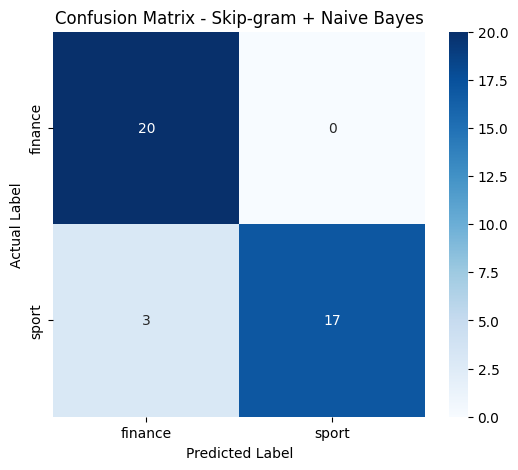

Jumlah prediksi salah: 3


,Data_Testing,Label_Aktual,Label_Prediksi,Status
13,14,1,0,Salah
16,17,1,0,Salah
28,29,1,0,Salah


In [29]:
cm = confusion_matrix(y_test_nb, y_pred, labels=[0, 1])
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["finance", "sport"],
    yticklabels=["finance", "sport"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Skip-gram + Naive Bayes")
plt.show()

df_salah = df_hasil_prediksi[df_hasil_prediksi["Status"] == "Salah"]
print("Jumlah prediksi salah:", len(df_salah))
display(df_salah)

## 29. Ringkasan Evaluasi
Merangkum seluruh metrik evaluasi model (Accuracy, Macro Precision, Macro Recall, Macro F1) ke dalam sebuah tabel ringkasan dan mengekspor hasil prediksi serta ringkasan evaluasi ke file Excel.

In [30]:
df_evaluasi = pd.DataFrame({
    "Model": ["Skip-gram + Naive Bayes"],
    "Jumlah_Training": [len(y_train_nb)],
    "Jumlah_Testing": [len(y_test_nb)],
    "Vector_Size": [VECTOR_SIZE],
    "Window": [WINDOW_SIZE],
    "Accuracy": [accuracy],
    "Precision_Macro": [precision],
    "Recall_Macro": [recall],
    "F1_Macro": [f1]
})
display(df_evaluasi)

df_hasil_prediksi.to_excel("hasil_prediksi_skipgram_naive_bayes.xlsx", index=False)
df_evaluasi.to_excel("evaluasi_skipgram_naive_bayes.xlsx", index=False)
print("Semua hasil berhasil disimpan:")
print("- data_skipgram_training.xlsx")
print("- data_skipgram_testing.xlsx")
print("- hasil_prediksi_skipgram_naive_bayes.xlsx")
print("- evaluasi_skipgram_naive_bayes.xlsx")

,Model,Jumlah_Training,Jumlah_Testing,Vector_Size,Window,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,Skip-gram + Naive Bayes,160,40,50,1,0.925,0.934783,0.925,0.924576


Semua hasil berhasil disimpan:
- data_skipgram_training.xlsx
- data_skipgram_testing.xlsx
- hasil_prediksi_skipgram_naive_bayes.xlsx
- evaluasi_skipgram_naive_bayes.xlsx
